<a href="https://colab.research.google.com/github/TaicirCheikhrouhou/IDSproject-QGAN-AE-RL-FL/blob/main/Data_Reconstruction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NSL-KDD Autoencoder-based Data Reconstruction and Augmentation
================================================================

This script reconstructs synthetic network intrusion samples from latent space
representations using a trained autoencoder. It focuses on minority attack classes
(R2L and Probe) to address class imbalance in the NSL-KDD dataset.

Pipeline:
1. Load pretrained autoencoder and preprocessing artifacts
2. Decode latent samples into feature space
3. Apply inverse transformations (numerical and categorical)
4. Validate synthetic data quality
5. Augment original dataset with synthetic samples

Author: [Your Name]
Date: January 2026

# Imports & Global Configuration

In [ ]:
import math
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from torch import nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
LATENT_DIM = 7


# AutoEncoder Definition

In [ ]:
class AutoEncoder(nn.Module):
    """
    Simple MLP AutoEncoder for non-linear feature extraction.
    """
    def __init__(self, input_dim, latent_dim=LATENT_DIM):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

# Load Preprocessing Objects


In [ ]:
process = torch.load(
    "preprocess.pt",
    map_location="cpu",
    weights_only=False
)

robust = process["robust"]
minmax = process["minmax"]

numeric_cols     = process["numeric_cols"]
categorical_cols = process["categorical_cols"]
cat_columns      = process["cat_columns"]
input_dim        = process["input_dim"]

NUMERIC_DIM = len(numeric_cols)
CAT_DIM     = len(cat_columns)

print("✔ preprocess.pt loaded")
print("Input dim:", input_dim)
print("Numeric:", NUMERIC_DIM, "| Categorical (one-hot):", CAT_DIM)

✔ preprocess.pt loaded
Input dim: 122
Numeric: 38 | Categorical (one-hot): 84


# Load Trained AutoEncoder

In [ ]:
ae = AutoEncoder(input_dim, LATENT_DIM)
ae.load_state_dict(torch.load("autoencoder.pt", map_location=DEVICE))
ae = ae.to(DEVICE)
ae.eval()

print("✔ AutoEncoder loaded")

✔ AutoEncoder loaded


# Load Synthetic Latent Samples


In [ ]:


r2l_samples   = np.load("/content/synthetic_R2L.npz")["data"]
probe_samples = np.load("/content/synthetic_Probe.npz")["data"]

print("R2L latent shape   :", r2l_samples.shape)
print("Probe latent shape :", probe_samples.shape)

R2L latent shape   : (30000, 7)
Probe latent shape : (30000, 7)


# Latent Decoding

In [ ]:

def decode_latent(latent_np):
    """
    Decode latent vectors back to original feature space.
    """
    latent_t = torch.tensor(latent_np, dtype=torch.float32).to(DEVICE)

    assert latent_t.device == next(ae.parameters()).device, \
        "Device mismatch between latent and model!"

    with torch.no_grad():
        X_rec = ae.decoder(latent_t)

    return X_rec.cpu().numpy()

X_r2l_rec   = decode_latent(r2l_samples)
X_probe_rec = decode_latent(probe_samples)

print("Decoded shapes:", X_r2l_rec.shape, X_probe_rec.shape)

Decoded shapes: (30000, 122) (30000, 122)


# Inverse Scaling (Numeric Features)

In [ ]:


def inverse_numeric(X_rec):
    """
    Reverse MinMax + Robust scaling.
    """
    X_num = X_rec[:, :NUMERIC_DIM]
    X_num = minmax.inverse_transform(X_num)
    X_num = robust.inverse_transform(X_num)
    return pd.DataFrame(X_num, columns=numeric_cols)

df_r2l_num   = inverse_numeric(X_r2l_rec)
df_probe_num = inverse_numeric(X_probe_rec)

# Decode Categorical Features

In [ ]:


def decode_categorical(X_rec):
    """
    Recover categorical features from one-hot encoding.
    """
    X_cat = X_rec[:, NUMERIC_DIM:]
    df_cat = pd.DataFrame(X_cat, columns=cat_columns)

    decoded = {}
    for col in categorical_cols:
        cols = [c for c in cat_columns if c.startswith(col + "_")]
        decoded[col] = (
            df_cat[cols]
            .idxmax(axis=1)
            .str.replace(col + "_", "")
        )

    return pd.DataFrame(decoded)

df_r2l_cat   = decode_categorical(X_r2l_rec)
df_probe_cat = decode_categorical(X_probe_rec)

# Merge Features & Assign Labels

In [ ]:


df_r2l   = pd.concat([df_r2l_num, df_r2l_cat], axis=1)
df_probe = pd.concat([df_probe_num, df_probe_cat], axis=1)

df_r2l["attack_type"]   = "R2L"
df_probe["attack_type"] = "Probe"

r2l_labels = [
    "ftp_write","guess_passwd","imap","multihop","phf","spy",
    "warezclient","warezmaster","sendmail","named",
    "snmpgetattack","snmpguess","xlock","xsnoop","worm"
]

probe_labels = ["ipsweep","nmap","portsweep","satan","mscan","saint"]

df_r2l["label"]   = np.random.choice(r2l_labels, size=len(df_r2l))
df_probe["label"] = np.random.choice(probe_labels, size=len(df_probe))

# Save Reconstructed Data

In [ ]:

df_r2l.to_csv("/content/R2L_reconstructed.csv", index=False)
df_probe.to_csv("/content/Probe_reconstructed.csv", index=False)

print("✔ Reconstruction completed")

✔ Reconstruction completed


# Load Real NSL-KDD Dataset & Attack Mapping

In [ ]:


train_url = (
    "https://raw.githubusercontent.com/defcom17/NSL_KDD/"
    "master/KDDTrain+.txt"
)

col_names = [
    "duration","protocol_type","service","flag","src_bytes","dst_bytes","land",
    "wrong_fragment","urgent","hot","num_failed_logins","logged_in",
    "num_compromised","root_shell","su_attempted","num_root",
    "num_file_creations","num_shells","num_access_files",
    "num_outbound_cmds","is_host_login","is_guest_login","count","srv_count",
    "serror_rate","srv_serror_rate","rerror_rate","srv_rerror_rate",
    "same_srv_rate","diff_srv_rate","srv_diff_host_rate",
    "dst_host_count","dst_host_srv_count","dst_host_same_srv_rate",
    "dst_host_diff_srv_rate","dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate","dst_host_serror_rate",
    "dst_host_srv_serror_rate","dst_host_rerror_rate",
    "dst_host_srv_rerror_rate","label","difficulty"
]

df_real = pd.read_csv(train_url, names=col_names)
df_real.drop(columns=["difficulty"], inplace=True)



attack_map = {
    "normal": "Normal",
    "back": "DoS","land": "DoS","neptune": "DoS","pod": "DoS",
    "smurf": "DoS","teardrop": "DoS",
    "ipsweep": "Probe","nmap": "Probe","portsweep": "Probe",
    "satan": "Probe","mscan": "Probe","saint": "Probe",
    "ftp_write": "R2L","guess_passwd": "R2L","imap": "R2L",
    "multihop": "R2L","phf": "R2L","spy": "R2L",
    "warezclient": "R2L","warezmaster": "R2L","sendmail": "R2L",
    "named": "R2L","snmpgetattack": "R2L","snmpguess": "R2L",
    "xlock": "R2L","xsnoop": "R2L","worm": "R2L"
}

df_real["attack_type"] = df_real["label"].map(attack_map)

df_real_r2l   = df_real[df_real["attack_type"] == "R2L"]
df_real_probe = df_real[df_real["attack_type"] == "Probe"]

# Validation & Statistical Comparison

In [ ]:
def validity_check(df):
    return {
        "NaN_ratio": df.isna().mean().mean(),
        "Negative_ratio": (df[numeric_cols] < 0).mean().mean()
    }

def stat_distance(real, synth):
    mean_diff = np.mean(np.abs(real.mean() - synth.mean()))
    std_diff  = np.mean(np.abs(real.std() - synth.std()))
    return mean_diff, std_diff

print("R2L validity  :", validity_check(df_r2l))
print("Probe validity:", validity_check(df_probe))

R2L validity  : {'NaN_ratio': np.float64(0.0), 'Negative_ratio': np.float64(0.48026315789473684)}
Probe validity: {'NaN_ratio': np.float64(0.0), 'Negative_ratio': np.float64(0.4071798245614035)}


# Visualization

In [ ]:

def plot_all_numeric_distributions(real_df, synth_df, title_prefix, cols, n_cols=4):
    n_rows = math.ceil(len(cols) / n_cols)
    plt.figure(figsize=(5 * n_cols, 3 * n_rows))

    for i, feat in enumerate(cols):
        plt.subplot(n_rows, n_cols, i + 1)
        plt.hist(real_df[feat], bins=40, density=True, alpha=0.6, label="Real")
        plt.hist(synth_df[feat], bins=40, density=True, alpha=0.6, label="Synthetic")
        plt.title(feat, fontsize=9)
        plt.grid(alpha=0.3)
        if i == 0:
            plt.legend()

    plt.suptitle(title_prefix, fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

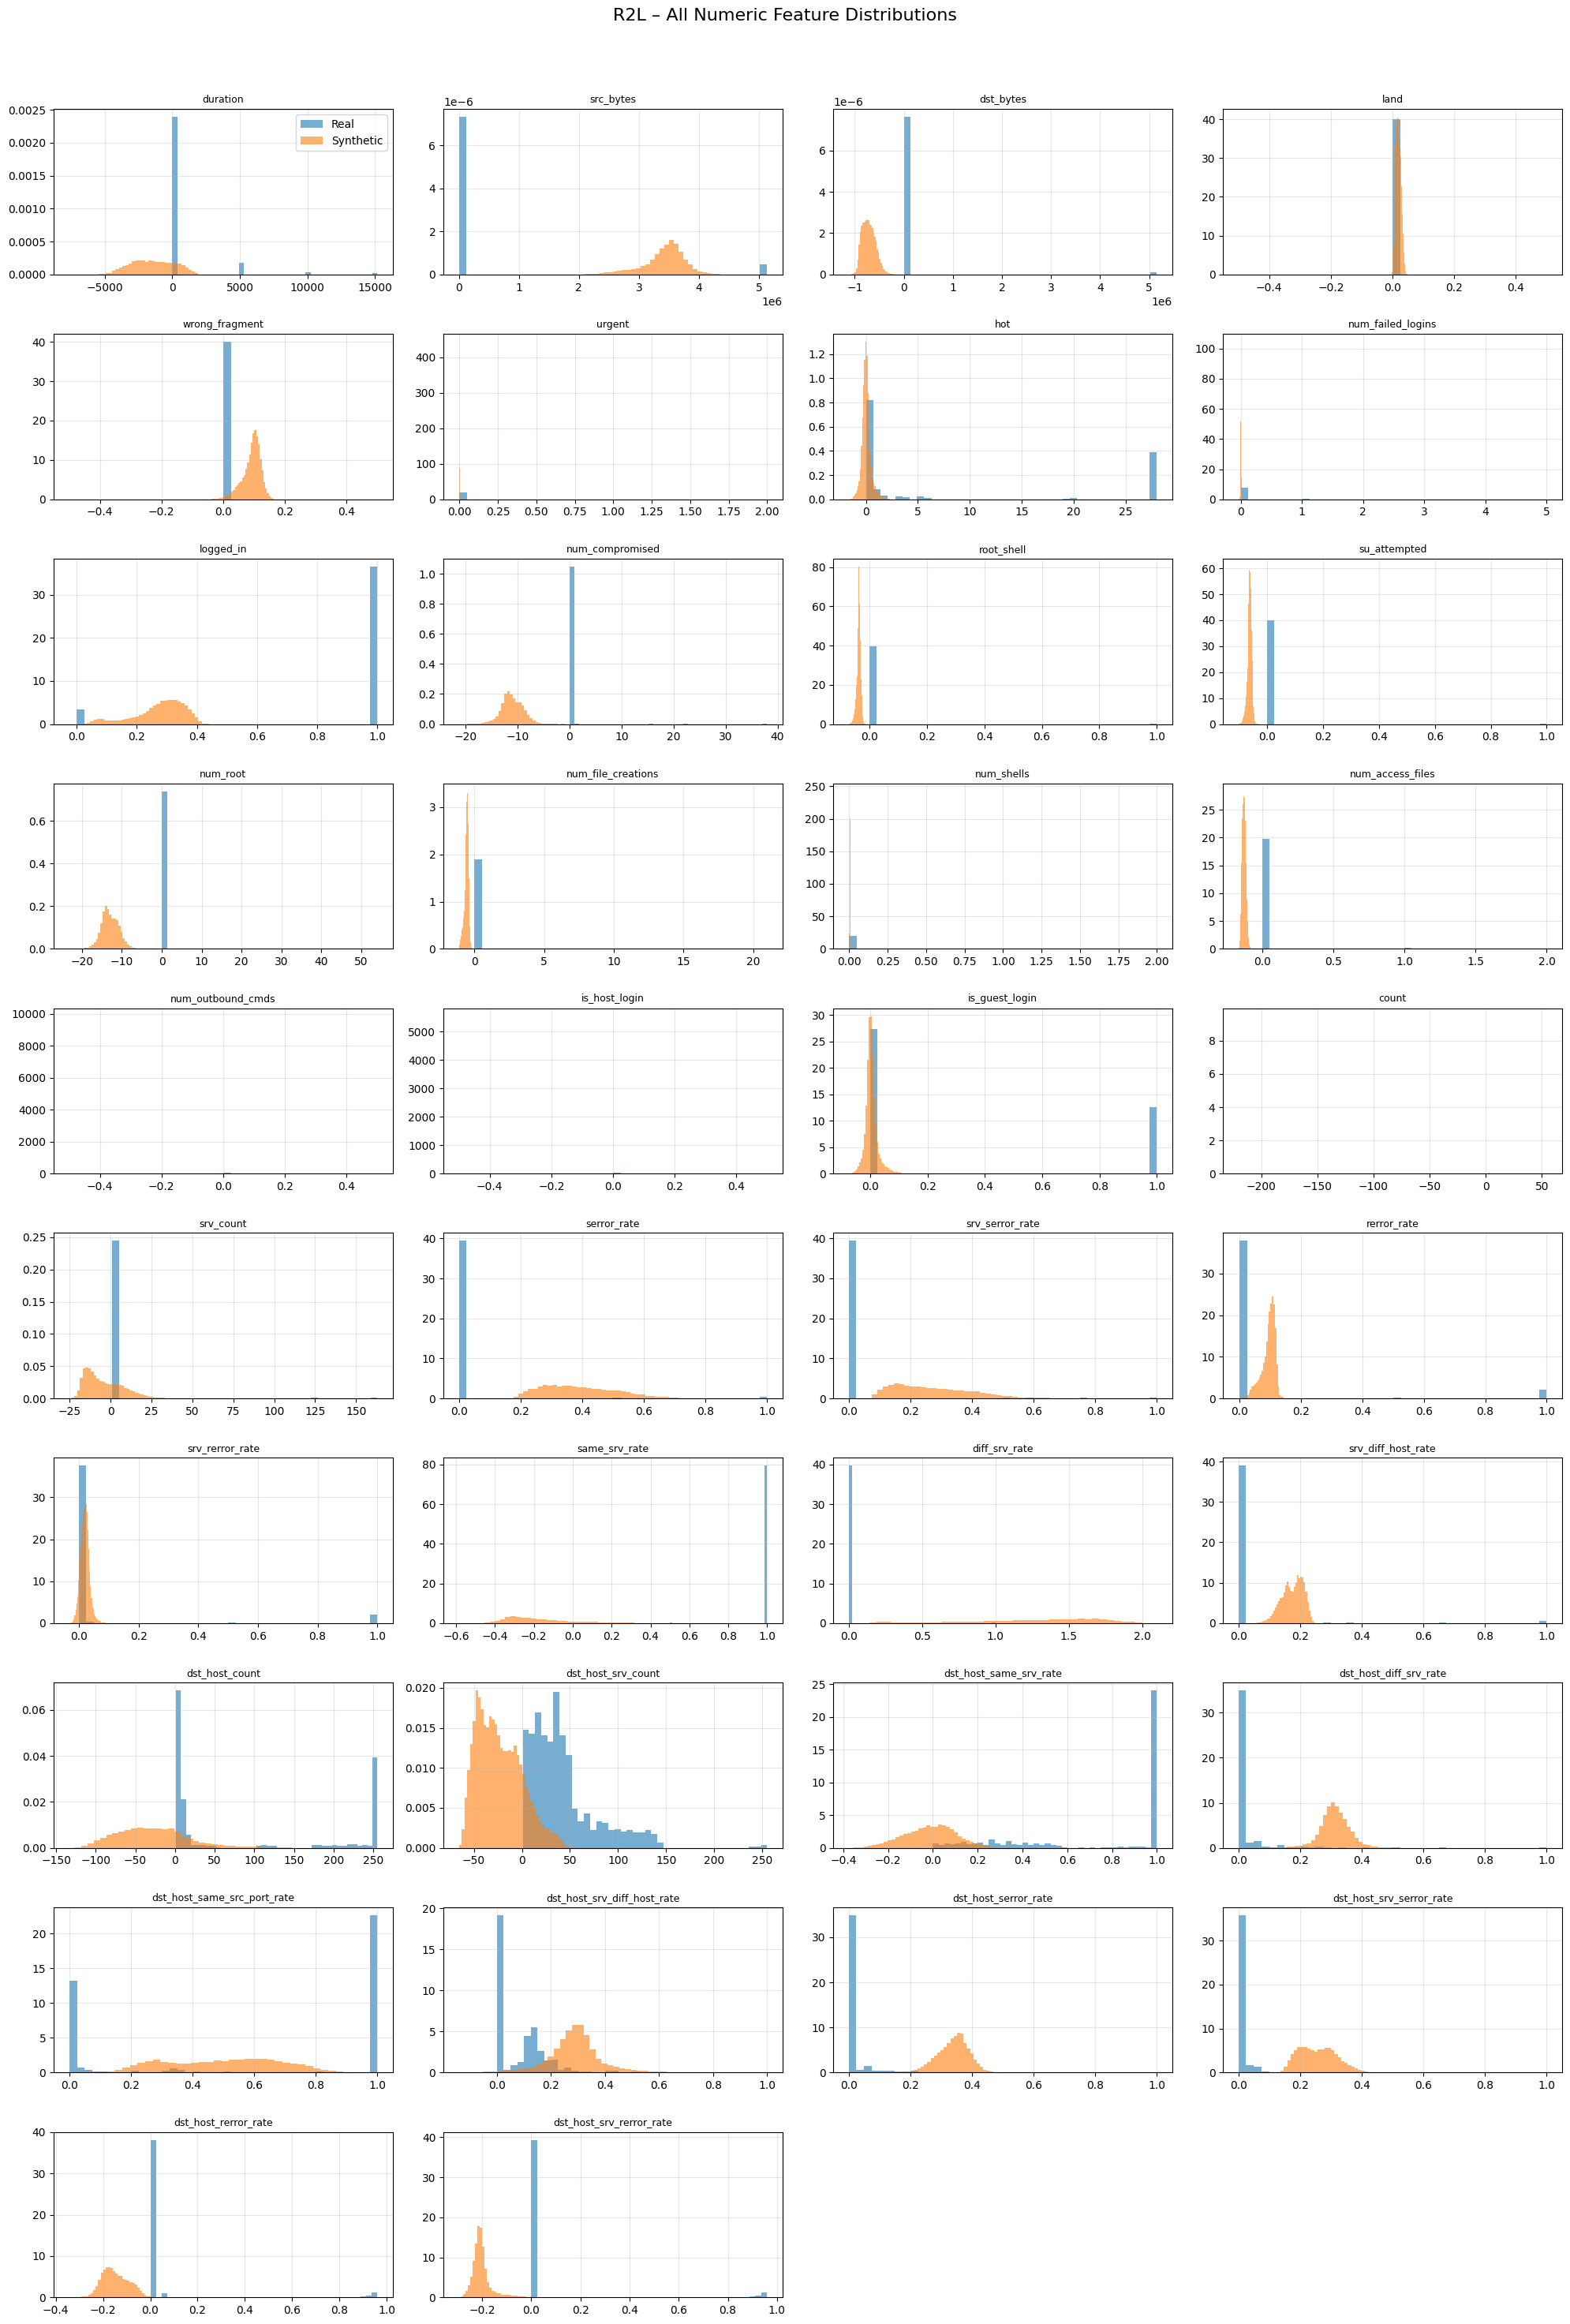

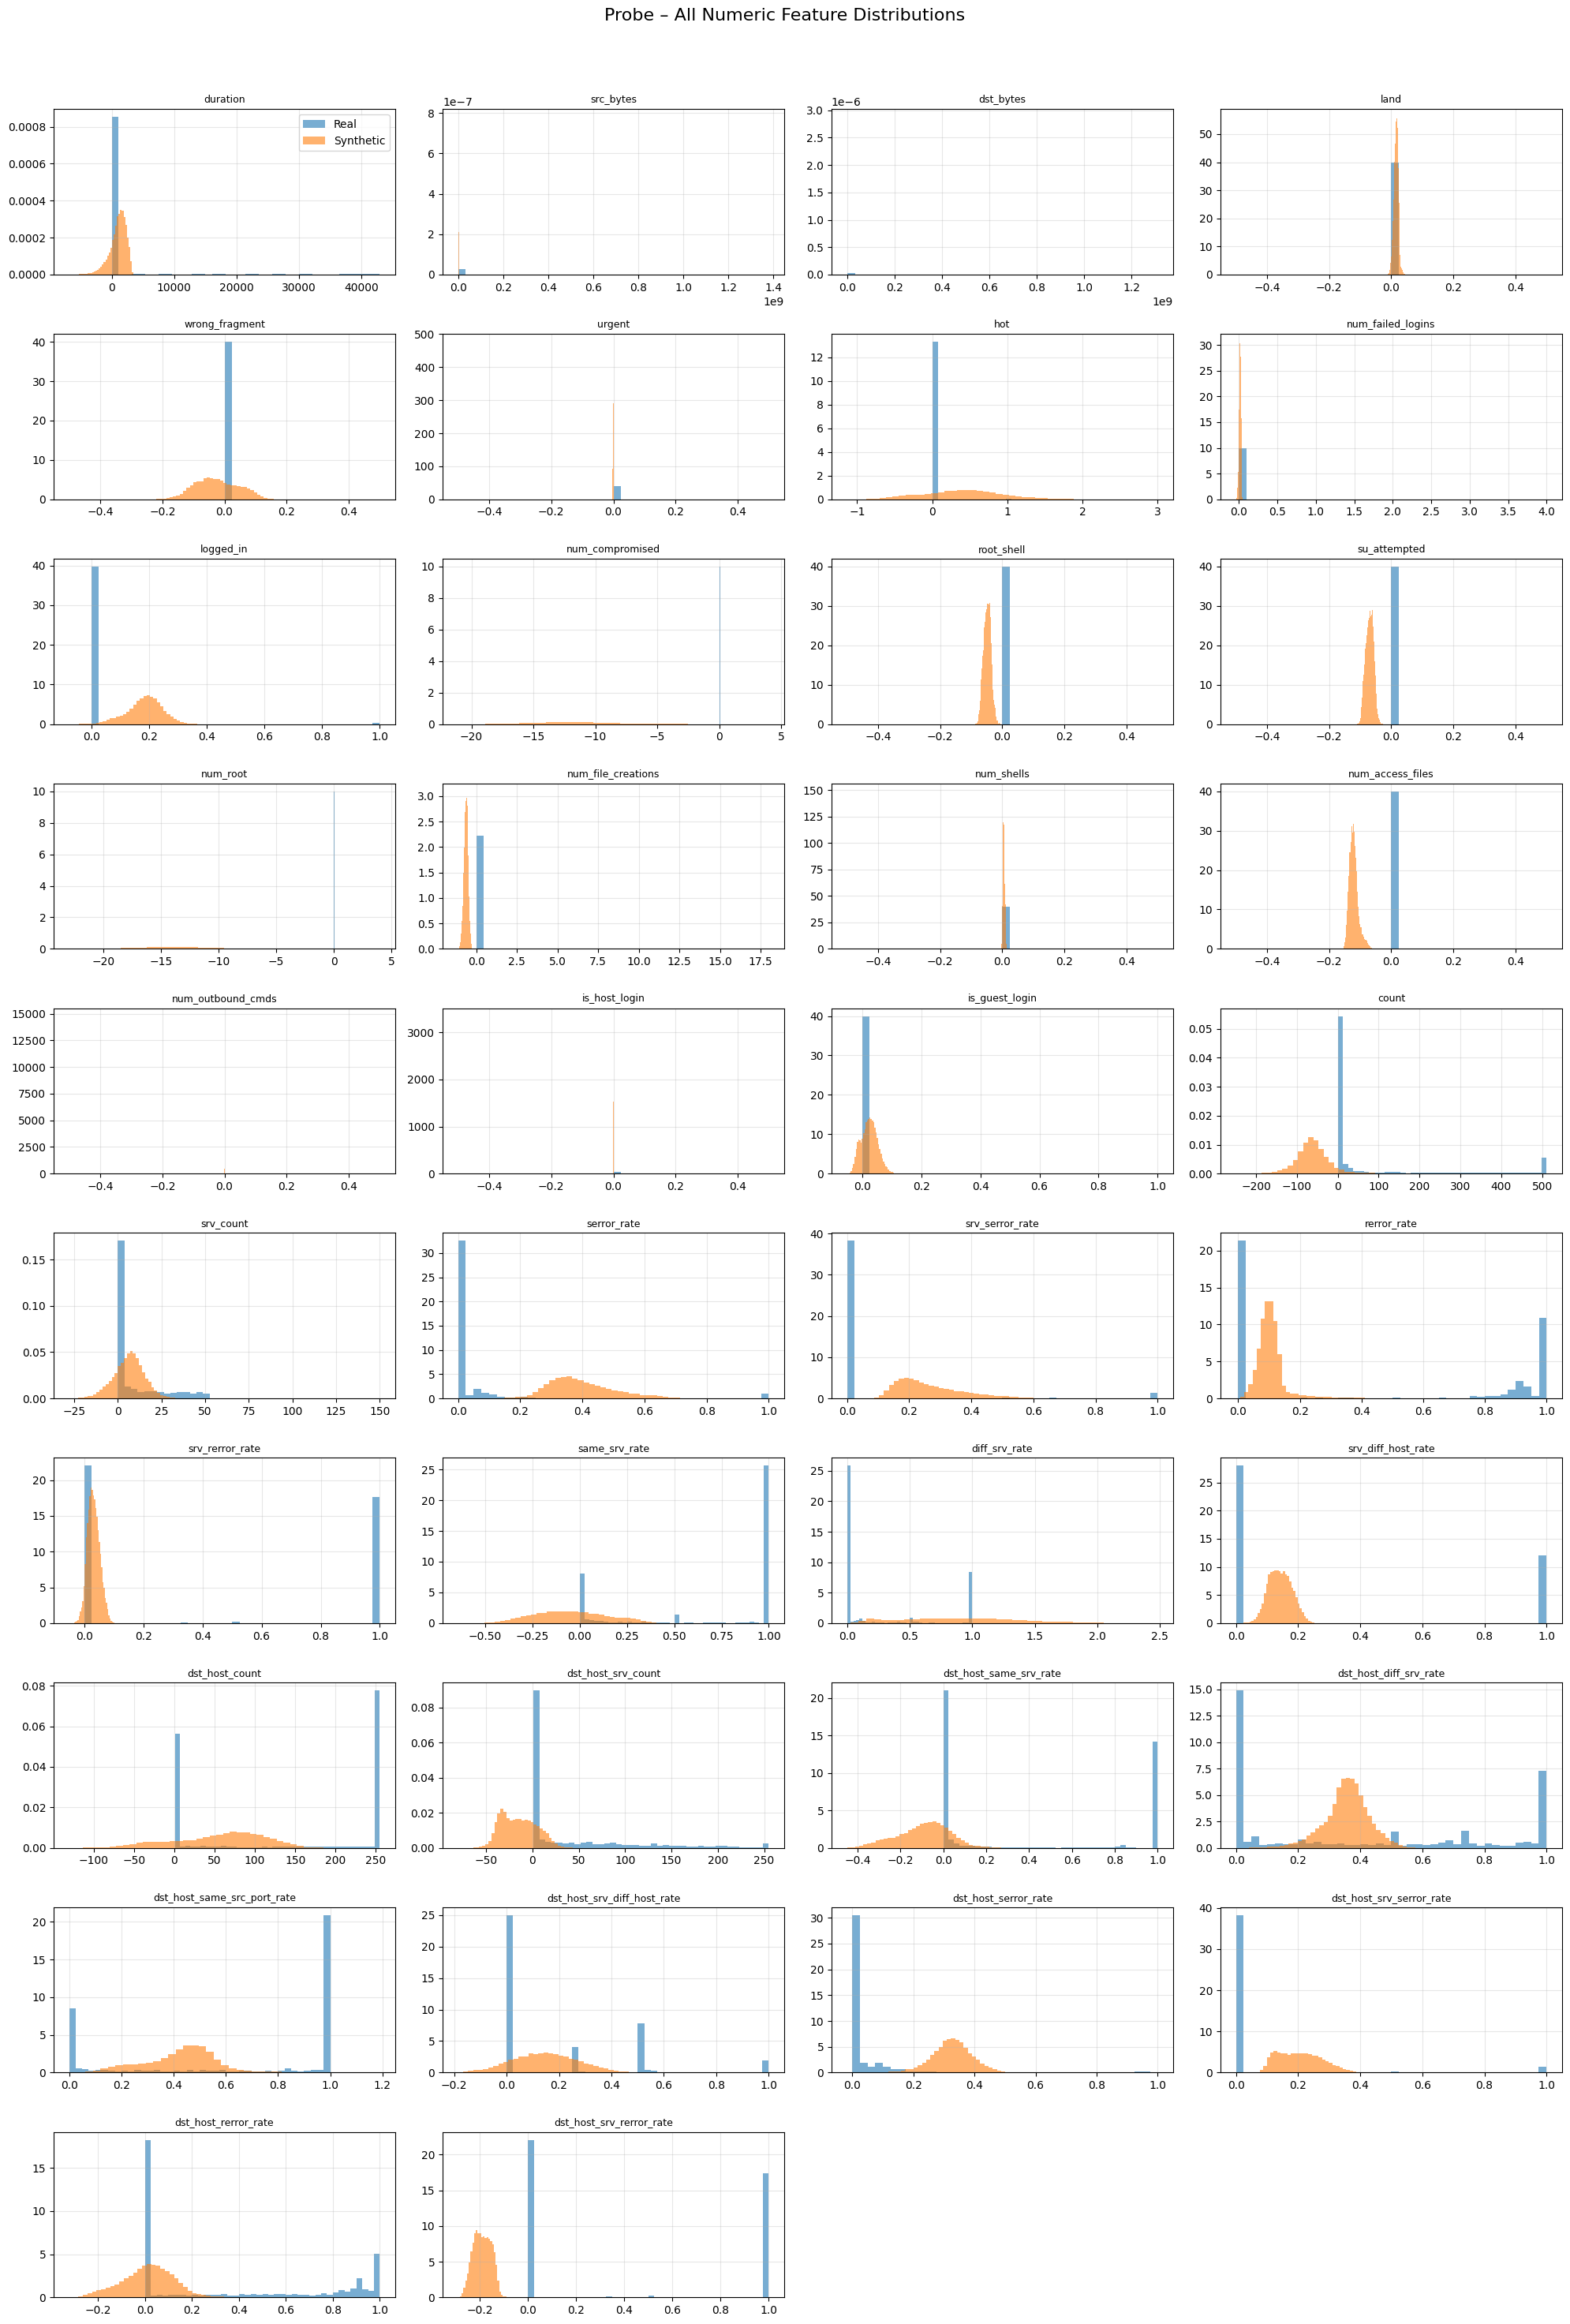

In [ ]:
plot_all_numeric_distributions(
    df_real_r2l,
    df_r2l,
    "R2L – All Numeric Feature Distributions",
    numeric_cols
)

plot_all_numeric_distributions(
    df_real_probe,
    df_probe,
    "Probe – All Numeric Feature Distributions",
    numeric_cols
)



# Dataset Augmentation & Export


In [ ]:


df_augmented = pd.concat([df_r2l, df_probe], axis=0)
df_augmented = df_augmented.sample(frac=1, random_state=42)

df_augmented.to_csv("/content/KDDTrain_AUGMENTED.csv", index=False)

df_augmented.to_csv(
    "/content/KDDTrain_AUGMENTED.txt",
    sep=",",
    index=False,
    header=False
)

print("✔ Augmented dataset saved (CSV + TXT)")


✔ Augmented dataset saved (CSV + TXT)


In [ ]:
# BEFORE augmentation
dist_before = (
    df_real["attack_type"]
    .value_counts()
    .sort_index()
    .rename("Before_Augmentation")
)

# ONLY synthetic data
df_augmented = pd.concat([df_r2l, df_probe], axis=0)

# AFTER augmentation
df_after = pd.concat([df_real, df_augmented], axis=0)

dist_after = (
    df_after["attack_type"]
    .value_counts()
    .sort_index()
    .rename("After_Augmentation")
)

# Comparison table
dist_compare = pd.concat([dist_before, dist_after], axis=1)
dist_compare



,Before_Augmentation,After_Augmentation
attack_type,,
DoS,45927,45927
Normal,67343,67343
Probe,11656,41656
R2L,995,30995
